<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/data_visualization/matplotlib/multiple_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# ikkita kompaniya aksiyasining (TechCorp va RetailCo) 2023 yildagi kunlik yopilish narxi ma'lumotlari
np.random.seed(72)

dates = pd.bdate_range(start='2023-01-01', end='2023-12-29')

df_stock_prices = pd.DataFrame({
    'date': dates,
    'techcorp_price': (150 + np.cumsum(np.random.normal(0.15, 2.5, len(dates)))).round(2),
    'retailco_price': (85 + np.cumsum(np.random.normal(0.02, 1.2, len(dates)))).round(2)
})

df_stock_prices.shape

(260, 3)

In [3]:
df_stock_prices.head()

,date,techcorp_price,retailco_price
0,2023-01-02,150.95,86.71
1,2023-01-03,149.40,86.34
2,2023-01-04,144.03,89.10
3,2023-01-05,145.65,88.99
4,2023-01-06,149.99,89.54


In [4]:
df_stock_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            260 non-null    datetime64[ns]
 1   techcorp_price  260 non-null    float64       
 2   retailco_price  260 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 6.2 KB


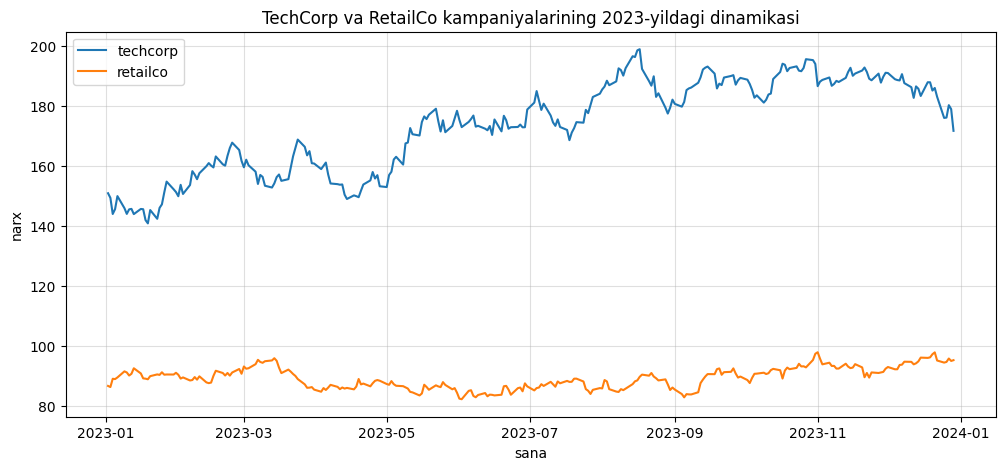

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(df_stock_prices['date'], df_stock_prices['techcorp_price'], label='techcorp')
plt.plot(df_stock_prices['date'], df_stock_prices['retailco_price'], label='retailco')

plt.title("TechCorp va RetailCo kampaniyalarining 2023-yildagi dinamikasi")
plt.xlabel("sana")
plt.ylabel("narx")
plt.grid(alpha=0.4)
plt.legend()

plt.show()

- TechCorp aksiyalari yil davomida ancha yuqori qiymatga ega bo'lgan bo'lsa, RetailCo nisbatan past narx oralig'ida harakat qilgan
- TechCorp aksiyalarida kuchli tebranishlar va aniq o'sish tendensiyasi kuzatilib, avgust oyida o'zining eng yuqori natijasiga erishgan . RetailCo aksiyalari esa yil davomida minimal tebranishlar qilib , bir tekisda ketgan
- Har ikki kompaniya ham yil boshiga nisbatan yil oxirini yuqoriroq narx ko'rsatkichlari bilan yakunlagan

In [30]:
# techcorp kampaniyasi moliyasini normalizatsiya qilish
df_stock_prices['tech_nor'] = (df_stock_prices['techcorp_price']/df_stock_prices.iloc[0]['techcorp_price'])*100
df_stock_prices.head()

,date,techcorp_price,retailco_price,tech_nor
0,2023-01-02,150.95,86.71,100.000000
1,2023-01-03,149.40,86.34,98.973170
2,2023-01-04,144.03,89.10,95.415701
3,2023-01-05,145.65,88.99,96.488904
4,2023-01-06,149.99,89.54,99.364028


In [31]:
# retailco kampaniyasi moliyasini normalizatsiya qilish
df_stock_prices['retail_nor'] = (df_stock_prices['retailco_price']/df_stock_prices.iloc[0]['retailco_price'])*100
df_stock_prices.head()

,date,techcorp_price,retailco_price,tech_nor,retail_nor
0,2023-01-02,150.95,86.71,100.000000,100.000000
1,2023-01-03,149.40,86.34,98.973170,99.573290
2,2023-01-04,144.03,89.10,95.415701,102.756314
3,2023-01-05,145.65,88.99,96.488904,102.629455
4,2023-01-06,149.99,89.54,99.364028,103.263753


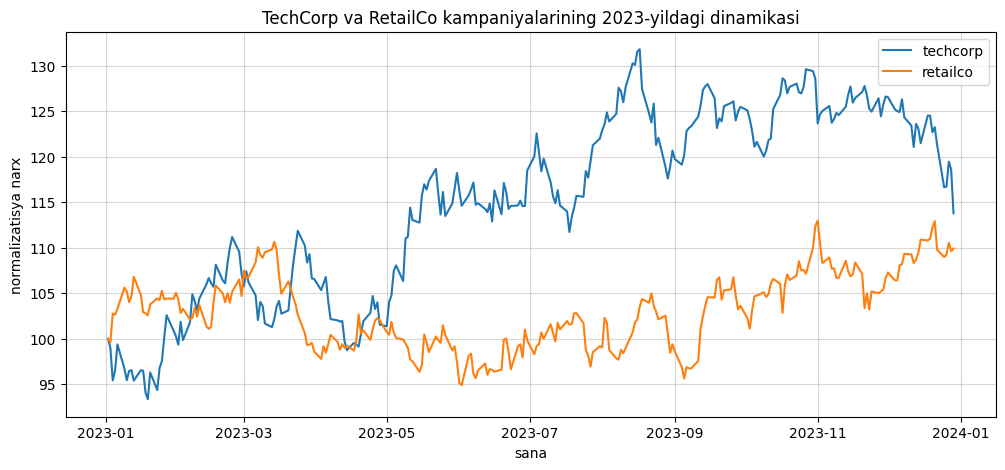

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(df_stock_prices['date'], df_stock_prices['tech_nor'], label='techcorp')
plt.plot(df_stock_prices['date'], df_stock_prices['retail_nor'], label='retailco')

plt.title("TechCorp va RetailCo kampaniyalarining 2023-yildagi dinamikasi")
plt.xlabel("sana")
plt.ylabel("normalizatisya narx")
plt.legend()
plt.grid(alpha=0.5)

plt.show()

- Ikkala kompaniya ham yil boshini bir xil boshlagan va yil so'ngiga borib o'sish bilan yakunlagan
- Martdan boshlab TechCorp kampaniyasi RetailCodan o'zib ketgan va Avgust oyida o'zining eng yuqori ko'rsatgichini qayd etgan
- RetailCo yil boshida pastlashni ko'rsatgan bo'lsa , yil so'ngida o'sishga erishgan

In [40]:
# veb-saytning 2023 yildagi oylik asosiy ko'rsatkichlari ma'lumotlari
np.random.seed(90)

df_website_metrics = pd.DataFrame({
    'month': pd.date_range(start='2023-01-01', periods=12, freq='MS'),
    'visitors': (15000 + np.cumsum(np.random.normal(600, 900, 12))).round(0).astype(int),
    'conversion_rate': np.clip(np.random.normal(3.2, 0.5, 12), 1.5, 6).round(2),
    'avg_session_minutes': np.clip(np.random.normal(4.5, 0.8, 12), 2, 8).round(2),
    'bounce_rate': np.clip(np.random.normal(42, 6, 12), 25, 65).round(1)
})

df_website_metrics.shape

(12, 5)

In [41]:
df_website_metrics

,month,visitors,conversion_rate,avg_session_minutes,bounce_rate
0,2023-01-01,15398,3.32,5.82,37.8
1,2023-02-01,15793,2.52,5.22,48.1
2,2023-03-01,15861,3.21,4.38,38.7
3,2023-04-01,15742,3.85,5.48,50.6
4,2023-05-01,17413,3.74,4.97,45.5
5,2023-06-01,16783,3.59,4.55,50.6
6,2023-07-01,18032,2.57,4.39,54.5
7,2023-08-01,17439,3.98,3.04,34.3
8,2023-09-01,19711,3.41,4.83,46.2
9,2023-10-01,21433,3.24,5.47,42.8


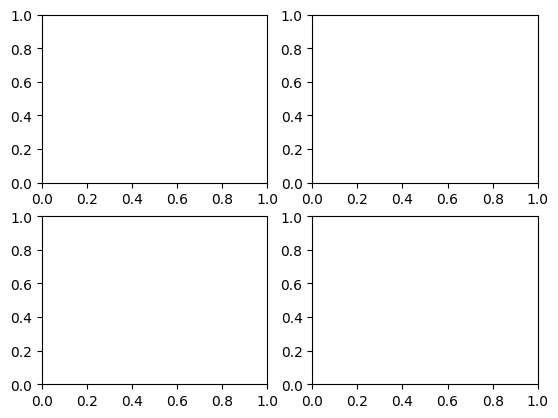

In [42]:
fig, ax = plt.subplots(2, 2)